---
tags: [tutorial]
---

# 再利用パターン：QKernelの合成とコンポジットゲート

回路が大きくなると、ゲート列のコピー＆ペーストを避けたくなります。Qamomileは2つの再利用メカニズムを提供しています：

1. **ヘルパーQKernel** — ある`@qkernel`を別の`@qkernel`から呼び出す、通常の関数合成と同じ方法です。
2. `@composite_gate` — 量子カーネルをカスタム可能な名前付きゲートに昇格させ、図中で単一のボックスとして表示します。

さらにトップダウン設計のための第3のパターンもあります：

3. **スタブゲート** — 実装本体を持たないゲートで、リソース推定に使います。例えば、グローバー探索アルゴリズムを設計しており、オラクルが約40個のTゲートを使用することはわかっているが、まだ実装していないとします。スタブゲートを使用すると、完全なオラクル実装なしでアルゴリズムの総コストを推定できます。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
import math

import qamomile.circuit as qmc
from qamomile.circuit.ir.operation.composite_gate import ResourceMetadata
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## パターン1:ヘルパーQKernel

どの`@qkernel`関数も別の`@qkernel`から呼び出せます。トランスパイル時にインライン展開されるため、トランスパイル結果はフラットな回路になります。

In [3]:
@qmc.qkernel
def entangle_once(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_helper(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_once(q[i], q[i + 1])

    return qmc.measure(q)

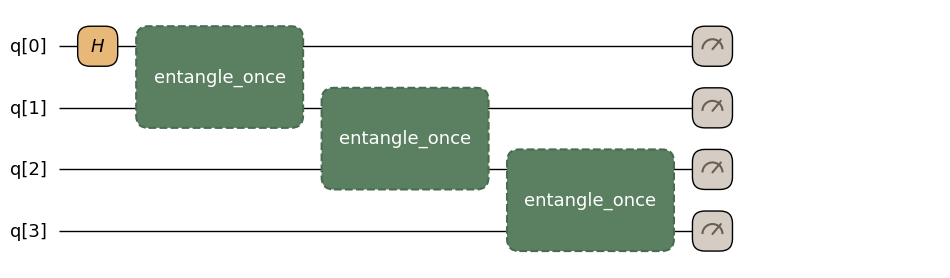

In [4]:
ghz_with_helper.draw(n=4, fold_loops=False)

In [5]:
result = (
    transpiler.transpile(ghz_with_helper, bindings={"n": 4})
    .sample(
        transpiler.executor(),
        shots=128,
    )
    .result()
)
print("GHZ result:", result.results)

GHZ result: [((1, 1, 1, 1), 62), ((0, 0, 0, 0), 66)]


ヘルパー`entangle_once`により、呼び出し側のコードが読みやすくなります。トランスパイル後の回路ではインライン展開されるため、サブブロックではなく個々のCXゲートが見えます。

In [6]:
qc = transpiler.to_circuit(ghz_with_helper, bindings={"n": 4})
print(qc.draw())

     ┌───┐          ┌─┐              
q_0: ┤ H ├──■───────┤M├──────────────
     └───┘┌─┴─┐     └╥┘     ┌─┐      
q_1: ─────┤ X ├──■───╫──────┤M├──────
          └───┘┌─┴─┐ ║      └╥┘┌─┐   
q_2: ──────────┤ X ├─╫───■───╫─┤M├───
               └───┘ ║ ┌─┴─┐ ║ └╥┘┌─┐
q_3: ────────────────╫─┤ X ├─╫──╫─┤M├
                     ║ └───┘ ║  ║ └╥┘
c: 4/════════════════╩═══════╩══╩══╩═
                     0       1  2  3 


### ヘルパーへのスカラーリテラルの受け渡し

ヘルパーqkernelがスカラー型(`UInt`,`Float`,`Bit`)のパラメータを宣言している場合、呼び出し側ではPythonの生のリテラルをそのまま渡せます。Qamomileが`int`を`UInt`、`float`を`Float`、`bool`を`Bit`に自動昇格します。`helper(q, 0, 0.5)`は`helper(q, qmc.uint(0), qmc.float_(0.5))`と等価です。明示的な`qmc.uint`/`qmc.float_`/`qmc.bit`コンストラクタは、値に名前を付けたい場合や複数の呼び出し箇所で共有したい場合にのみ使えば十分です。

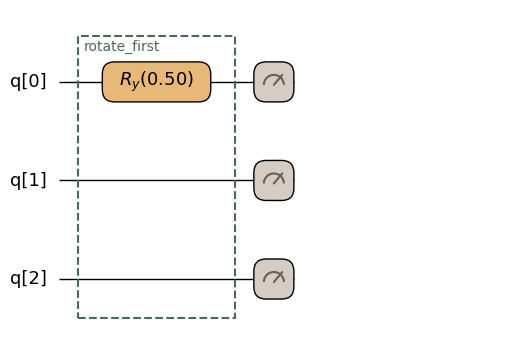

In [7]:
@qmc.qkernel
def rotate_first(
    q: qmc.Vector[qmc.Qubit],
    idx: qmc.UInt,
    angle: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    q[idx] = qmc.ry(q[idx], angle)
    return q


@qmc.qkernel
def helper_with_literals(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q = rotate_first(q, 0, 0.5)  # int・floatリテラルをそのまま渡せる
    return qmc.measure(q)


helper_with_literals.draw(n=3, fold_loops=False, inline=True)

## パターン2：`@composite_gate`

再利用可能なブロックを回路図で**名前付きボックス**として表示したい場合`@composite_gate`でを使うこともできます。また、より高度な内容としてコンポジットゲートにすることで複数の実装方式を与えるといったカスタム設定を与えることも可能です。

`@qkernel`の上に`@composite_gate(name="...")`を重ねて書きます：

In [8]:
@qmc.composite_gate(name="entangle")
@qmc.qkernel
def entangle_link(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_composite(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_link(q[i], q[i + 1])

    return qmc.measure(q)

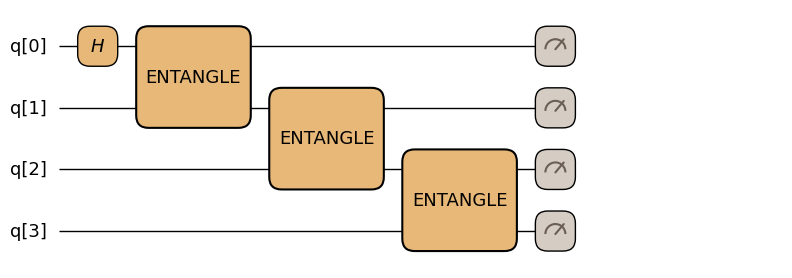

In [9]:
ghz_with_composite.draw(n=4, fold_loops=False)

### どちらを使うべきか?

| パターン | `draw()`での表示 | 使用場面 |
|---------|-------------------|--------------------------|
| ヘルパー`@qkernel` | インライン展開(フラット) | コードの整理 |
| `@composite_gate` | 名前付きボックス | ドメインレベルの抽象化/高度なカスタム |

## パターン3:トップダウン設計のためのスタブゲート

オラクルなどを想定する量子アルゴリズムを設計する場合に内部は未知のまま回路を組みたいこともあると思います。**スタブゲート**は実装本体を持たず、名前・量子ビット数・オプションのリソースメタデータだけを持ちます。

オラクルあるいはサブルーチンが開発中でも、アルゴリズム全体のコストを推定できます。

スタブゲートを使うためには`@composite_gate`の引数として`stub=True`を指定します。このとき同時にリソース情報を`ResrouceMetadata`として与えられます。

In [10]:
@qmc.composite_gate(
    stub=True,
    name="oracle",
    num_qubits=3,
    resource_metadata=ResourceMetadata(
        query_complexity=1,
        t_gates=40,
    ),
)
def oracle_box():
    pass


@qmc.qkernel
def algorithm_skeleton() -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")
    q = qmc.h(q)

    q[0], q[1], q[2] = oracle_box(q[0], q[1], q[2])
    return q

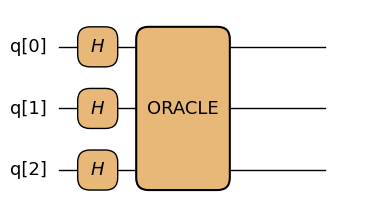

In [11]:
algorithm_skeleton.draw(fold_loops=False)

### スタブゲートを含むqkernelのリソース推定

`estimate_resources()`は、オラクル内部が未実装でもqkernel全体を解析できます。既知の回路部分は通常どおり集計され、未知のスタブ部分は`est.gates.oracle_calls` / `est.gates.oracle_queries`として追跡されます。

In [12]:
est = algorithm_skeleton.estimate_resources().simplify()
print("qubits:", est.qubits)
print("total gates:", est.gates.total)

qubits: 3
total gates: 3


次に、通常ゲートと複数スタブオラクルを混在させたqkernelで確認します。

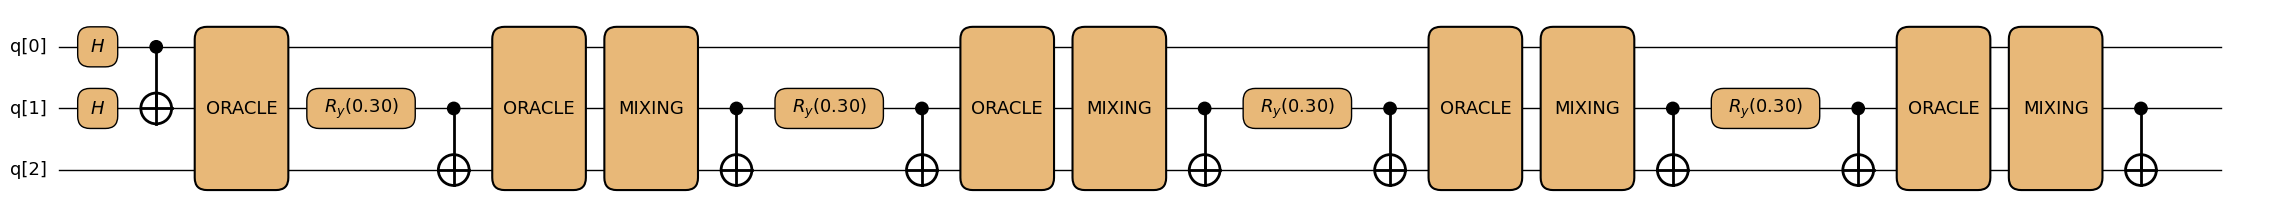

In [13]:
@qmc.composite_gate(
    stub=True,
    name="oracle",
    num_qubits=3,
    resource_metadata=ResourceMetadata(query_complexity=2),
)
def phase_oracle():
    pass


@qmc.composite_gate(
    stub=True,
    name="mixing",
    num_qubits=3,
    resource_metadata=ResourceMetadata(query_complexity=1),
)
def mixing_oracle():
    pass


@qmc.qkernel
def iterative_oracle_skeleton(rounds: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")

    # 既知の回路部分（非オラクル）
    q[0] = qmc.h(q[0])
    q[1] = qmc.h(q[1])
    q[0], q[1] = qmc.cx(q[0], q[1])

    # ループ外で 1 回オラクル呼び出し
    q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])

    # 各ラウンドで既知ゲートと未知オラクルを混在
    for i in qmc.range(rounds):
        q[1] = qmc.ry(q[1], 0.3)
        q[1], q[2] = qmc.cx(q[1], q[2])
        q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])
        q[0], q[1], q[2] = mixing_oracle(q[0], q[1], q[2])
        q[1], q[2] = qmc.cx(q[1], q[2])

    return q


iterative_oracle_skeleton.draw(rounds=4, fold_loops=False)

In [14]:
oracle_est = iterative_oracle_skeleton.estimate_resources().simplify()
print("total gates:", oracle_est.gates.total)
print("two-qubit gates:", oracle_est.gates.two_qubit)
print("oracle_calls:", oracle_est.gates.oracle_calls)
print("oracle_queries:", oracle_est.gates.oracle_queries)

total gates: 3*rounds + 3
two-qubit gates: 2*rounds + 1
oracle_calls: {'oracle': rounds + 1, 'mixing': rounds}
oracle_queries: {'oracle': 2*rounds + 2, 'mixing': rounds}


`rounds`に具体的な値を代入して、数値的なカウントを確認します：

In [15]:
oracle_est_4 = oracle_est.substitute(rounds=4)
print("oracle_calls (rounds=4):", oracle_est_4.gates.oracle_calls)
print("oracle_queries (rounds=4):", oracle_est_4.gates.oracle_queries)

oracle_calls (rounds=4): {'oracle': 5, 'mixing': 4}
oracle_queries (rounds=4): {'oracle': 10, 'mixing': 4}


この例のように、オラクル内部が不明でも回路解析を進められます。既知部分は通常通りカウントされ、未知オラクル部分は`oracle_calls`（例: `{'phase_oracle': rounds + 1, 'mixing_oracle': rounds}`）と`oracle_queries`（`query_complexity`で重み付け）として追跡されます。

このように完全な分解を実装する前にアルゴリズムレベルのコスト（量子ビット数、オラクルクエリ数等）を確認できます。

## パターン4:組み込みゲートをそのままcontrol化

単一のプリミティブゲート(`qmc.rx`、`qmc.h`、`qmc.cp`など)をcontrol化したいだけの場合、`qmc.control`は組み込みゲート関数を直接受け取れます。`@qkernel`ラッパーは不要です。古典パラメータのキーワード名は元のゲートのパラメータ名に従います(例:`qmc.rx`/`qmc.ry`なら`angle=`、`qmc.p`/`qmc.cp`なら`theta=`)。

**これまで** — ボイラープレートのラッパー:

```python
@qmc.qkernel
def _rx_gate(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    return qmc.rx(q, theta)

crx = qmc.control(_rx_gate)
```

**これから** — そのまま渡せる:

```python
crx = qmc.control(qmc.rx)
```

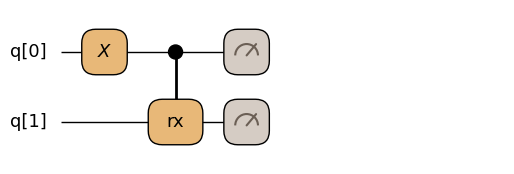

In [16]:
@qmc.qkernel
def controlled_rx_demo() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, name="q")
    # control側を|1>にしてcontrol回転を発火させる
    q[0] = qmc.x(q[0])
    crx = qmc.control(qmc.rx)
    q[0], q[1] = crx(q[0], q[1], angle=math.pi)
    return qmc.measure(q)


controlled_rx_demo.draw()

多重コントロールや`power`パラメータも他の`control(...)`と同じく動きます。`num_controls`と`power`は`ControlledGate`側の機能でラップ対象の関数とは独立しているため、追加の作業は不要です:

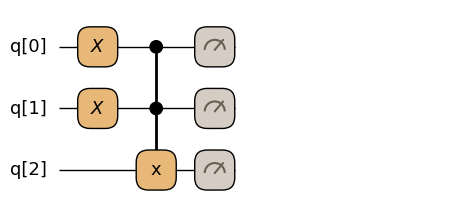

In [17]:
@qmc.qkernel
def toffoli_via_builtin() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(3, name="q")
    q[0] = qmc.x(q[0])
    q[1] = qmc.x(q[1])
    ccx = qmc.control(qmc.x, num_controls=2)
    q[0], q[1], q[2] = ccx(q[0], q[1], q[2])
    return qmc.measure(q)


toffoli_via_builtin.draw()

既存の`@qmc.qkernel`引数も従来どおり動きます。今回の組み込みゲート受け入れは純粋に追加の機能です。ゲート本体が単一プリミティブ呼び出し以上のもの(例えばHのあとにRX)を含む場合は、これまでどおり手書きの`@qkernel`を使ってください。複数ゲートからなる本体をcontrol化したいときこそ`@qkernel`の出番です:

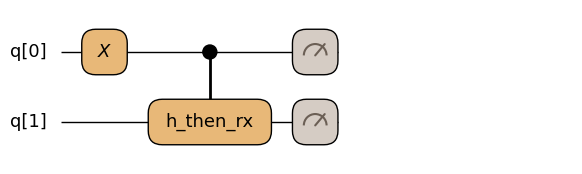

In [18]:
@qmc.qkernel
def h_then_rx(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    q = qmc.h(q)
    q = qmc.rx(q, theta)
    return q


@qmc.qkernel
def controlled_pair_demo() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, name="q")
    q[0] = qmc.x(q[0])
    cg = qmc.control(h_then_rx)
    q[0], q[1] = cg(q[0], q[1], theta=math.pi / 4)
    return qmc.measure(q)


controlled_pair_demo.draw()

## まとめ

- ヘルパー`@qkernel`：ある量子カーネルから別の量子カーネルを呼び出してコードを再利用できます。トランスパイラがインライン展開し、結果はフラットな回路になります。
- `@composite_gate`：量子カーネルに名前付きの識別子を与え、図で一つのゲートとして可視化します。`@qkernel`の上に`@composite_gate`デコレータを重ねて書きます。
- **スタブゲート**：`stub=True`と`ResourceMetadata`で、実装なしにトップダウン設計とリソース推定が可能です。
- `est.gates.oracle_calls`：オラクル内部が不明な状態でも、呼び出し回数を名前別の辞書として確認できます（シンボリックな回数もそのまま扱えます）。
- **`qmc.control(builtin_gate)`**:単一のプリミティブをcontrol化するときの1行`@qkernel`ラッパーは不要です。`qmc.rx`、`qmc.h`、`qmc.cp`等をそのままファクトリに渡せます。